In [1]:
from sympy import *
x, y, z = symbols('x y z')
init_printing(use_unicode=True)

Derivatives

to take derivatives, use the diff() func

In [2]:
diff(cos(x), x)

In [3]:
diff(exp(x**2), x)

In [4]:
# to find the 3rd derivative of x**4
diff(x**4, x, x, x)

In [5]:
#or use
diff(x**4, x, 3)

In [6]:
# You can also take derivatives with respect to many variables at once.
expr = exp(x*y*z)
expr

In [7]:
diff(expr, x, y, y, z, z, z, z)

In [8]:
# or use
diff(expr, x, y, 2, z, 4)

In [9]:
# diff can also be called as a method
expr.diff(x, y, 2, z, 4)

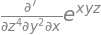

In [10]:
# to create an unevaluated derivative, use the Derivative class
deriv = Derivative(expr, x, y, y, z, 4)
deriv

In [11]:
# to evaluate an unevaluated derivative, use the doit() method
deriv.doit()

In [12]:
# Derivatives of unspecified order can be created using tuple(x, n)
# where n is the order of the derivative with respect to x
m, n, a, b = symbols('m n a b')
expr = (a*x + b)**m
expr.diff((x, n))

Integrals - use integrate()

(The antiderivative or primitive) There are 2 kinds of integrals - definite and indefinite

In [13]:
integrate(cos(x), x)

In [14]:
integrate(exp(-x**2 - y**2), (x,-oo, oo), (y, -oo, oo))

In [15]:
expr = integrate(x**x, x)
print(expr)

Integral(x**x, x)


In [16]:
expr

In [17]:
# as with Derivative, you can create an unevaluated integral using Integral
# to later evaluate this integrtl, call doit()
expr = Integral(log(x)**2,x)
expr

In [18]:
expr.doit()

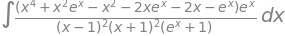

In [19]:
# some power of integral()
integ = Integral((x**4 + x**2*exp(x) - x**2 - 2*x*exp(x) - 2*x - exp(x)) * exp(x)/ ((x - 1)**2*(x + 1)**2*(exp(x) + 1)), x)
integ

In [20]:
integ.doit()

In [21]:
integ = Integral(sin(x**2), x)
integ

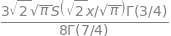

In [22]:
integ.doit()

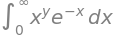

In [23]:
integ = Integral(x**y*exp(-x), (x, 0, oo))
integ

In [24]:
integ.doit()

⎧ Γ(y + 1)    for re(y) > -1
⎪                           
⎪∞                          
⎪⌠                          
⎨⎮  y  -x                   
⎪⎮ x ⋅ℯ   dx    otherwise   
⎪⌡                          
⎪0                          
⎩                           

Numeric Integration

to estimate the definite integral of a function across a simplified range.

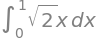

In [25]:
from sympy import Integral, Symbol, sqrt
x = Symbol('x')
integral = Integral(sqrt(2)*x, (x, 0, 1))
integral

In [26]:
integral.evalf()

In [27]:
# to compute the integral with a specified precision
integral.evalf(50)

In [28]:
# Numeric integration becomes a viable approach in situations where 
# symbolic integration is impractical or impossible
Integral(exp(-(x**2)), (x, -oo, oo)).evalf()

In [29]:
Integral(1/sqrt(x), (x, 0, 1)).evalf()

Limits

The syntex of limit in Sympy  limit(f(x), x, x0)

In [30]:
limit(sin(x) / x, x, 0)

In [31]:
# limit() should be used instead of subs() whenever the point of evaluation is a singularity.
# subs() do not keep track of things like rate of growth.
# Also, things like oo, -oo and oo/oo return nan. Example:
expr = x**2 / exp(x)
expr.subs(x, oo)


In [32]:
limit(expr, x, oo)

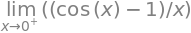

In [33]:
# limit() has an unevaluated counterpart, Limit
# to evaluate it, use doit()
expr = Limit((cos(x) - 1) / x, x, 0)
expr

In [34]:
expr.doit()

In [35]:
# to evaluate a limit at one side only, pass '+' or '-'
limit(1/x, x, 0, '+')

In [36]:
limit(1/x, x, 0, '-')

Sympy can compute asymptotic series expressions of functions around a point.


In [37]:
expr = exp(sin(x))
expr.series(x, 0, 4)

In [38]:
x + x**3 + x**6 + O(x**4)

In [39]:
x*O(1)

In [40]:
# if you do not want the order term, use the remove() method
expr.series(x, 0, 4).removeO()

In [41]:
# the O notation supports arbitrary limit points (other than O)
exp(x - 6).series(x, x0=6)

Finite differences

what if we want to have an expression to estimate a derivative of a curve

for which we lack a closed form representation,

or for which we don't know the functional values for yet

One approach would be to use a finite difference approach

In [42]:
f, g = symbols('f g', cls=Function)
differentiate_finite(f(x)*g(x))

In [43]:
# if you already have a Derivative instance, you can use the as_finite_difference() method
# to general approximations of the derivative to arbitrary order.
f = Function('f')
dfdx = f(x).diff(x)
dfdx.as_finite_difference()

here the first order derivative was approximated around x using a minimum number of points

(2 for 1st order derivative) evaluated equidistantly using a step size of 1

We can use arbitrary steps (possibly containing symbolic expressions)

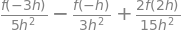

In [44]:
f = Function('f')
d2fdx2 = f(x).diff(x, 2)
h = Symbol('h')
d2fdx2.as_finite_difference([-3*h, -h, 2*h])

In [45]:
# if you are just interested in evaluating the weights, you can do so manually
finite_diff_weights(2, [-3, -1, 2], 0)[-1][-1]

In [46]:

# in using finite_diff_weights directly looks complicated,
# and the as_finite_difference() method of Derivative instances is not flexible enough,
# you can use apply_tinite_diff which takes order, x_list, y_list and x0 as parameters
x_list = [-3, 1, 2]
y_list = symbols('a b c')
apply_finite_diff(1, x_list, y_list, 0)
